# Оцениваем кредитный риск

### Подключаем библиотеки

In [1]:
import pandas as pd

from pet_project_credit.data_loader import build_modeling_tables
from pet_project_credit.preprocessing import feature_engineering
from pet_project_credit.train_model import run_training_pipeline
from pet_project_credit.visualization import (
    plot_baseline_curves,
    plot_baseline_metric_bars,
    plot_categorical_target_rates,
    plot_credit_amount_by_target,
    plot_default_rate_by_credit_amount,
    plot_feature_count_experiment,
    plot_feature_importance,
    plot_income_and_age_distributions,
    plot_numeric_distributions,
    plot_target_distribution,
)


## Готовим данные

### Загружаем данные

In [4]:
train = pd.read_csv('data/processed/train_processed.csv')
test = pd.read_csv('data/processed/test_processed.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")


Train shape: (307511, 252)
Test shape: (48744, 251)


## Изучаем данные

### Строим распределение

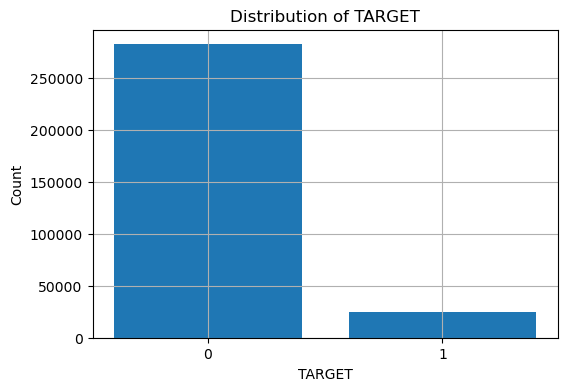

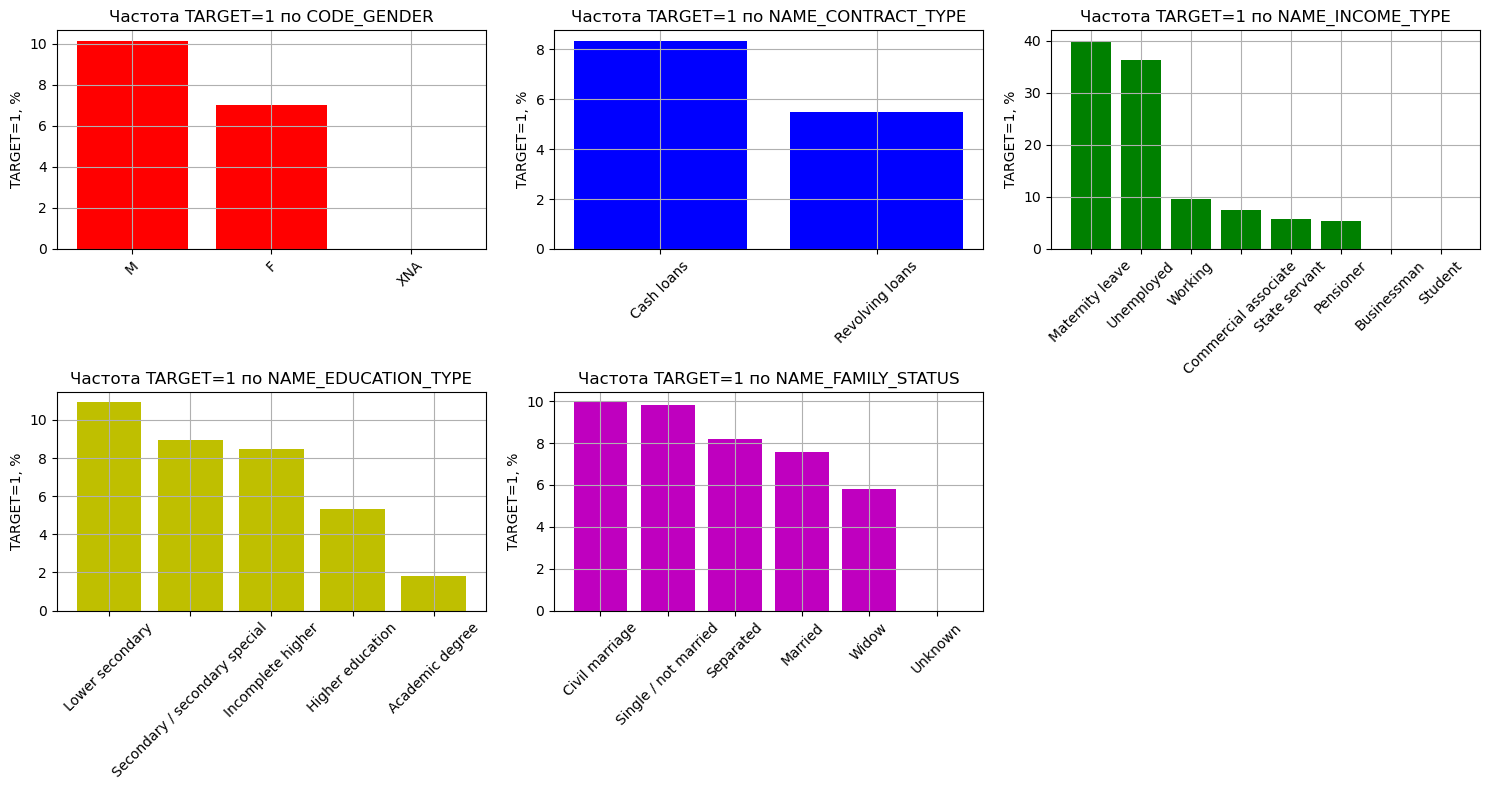

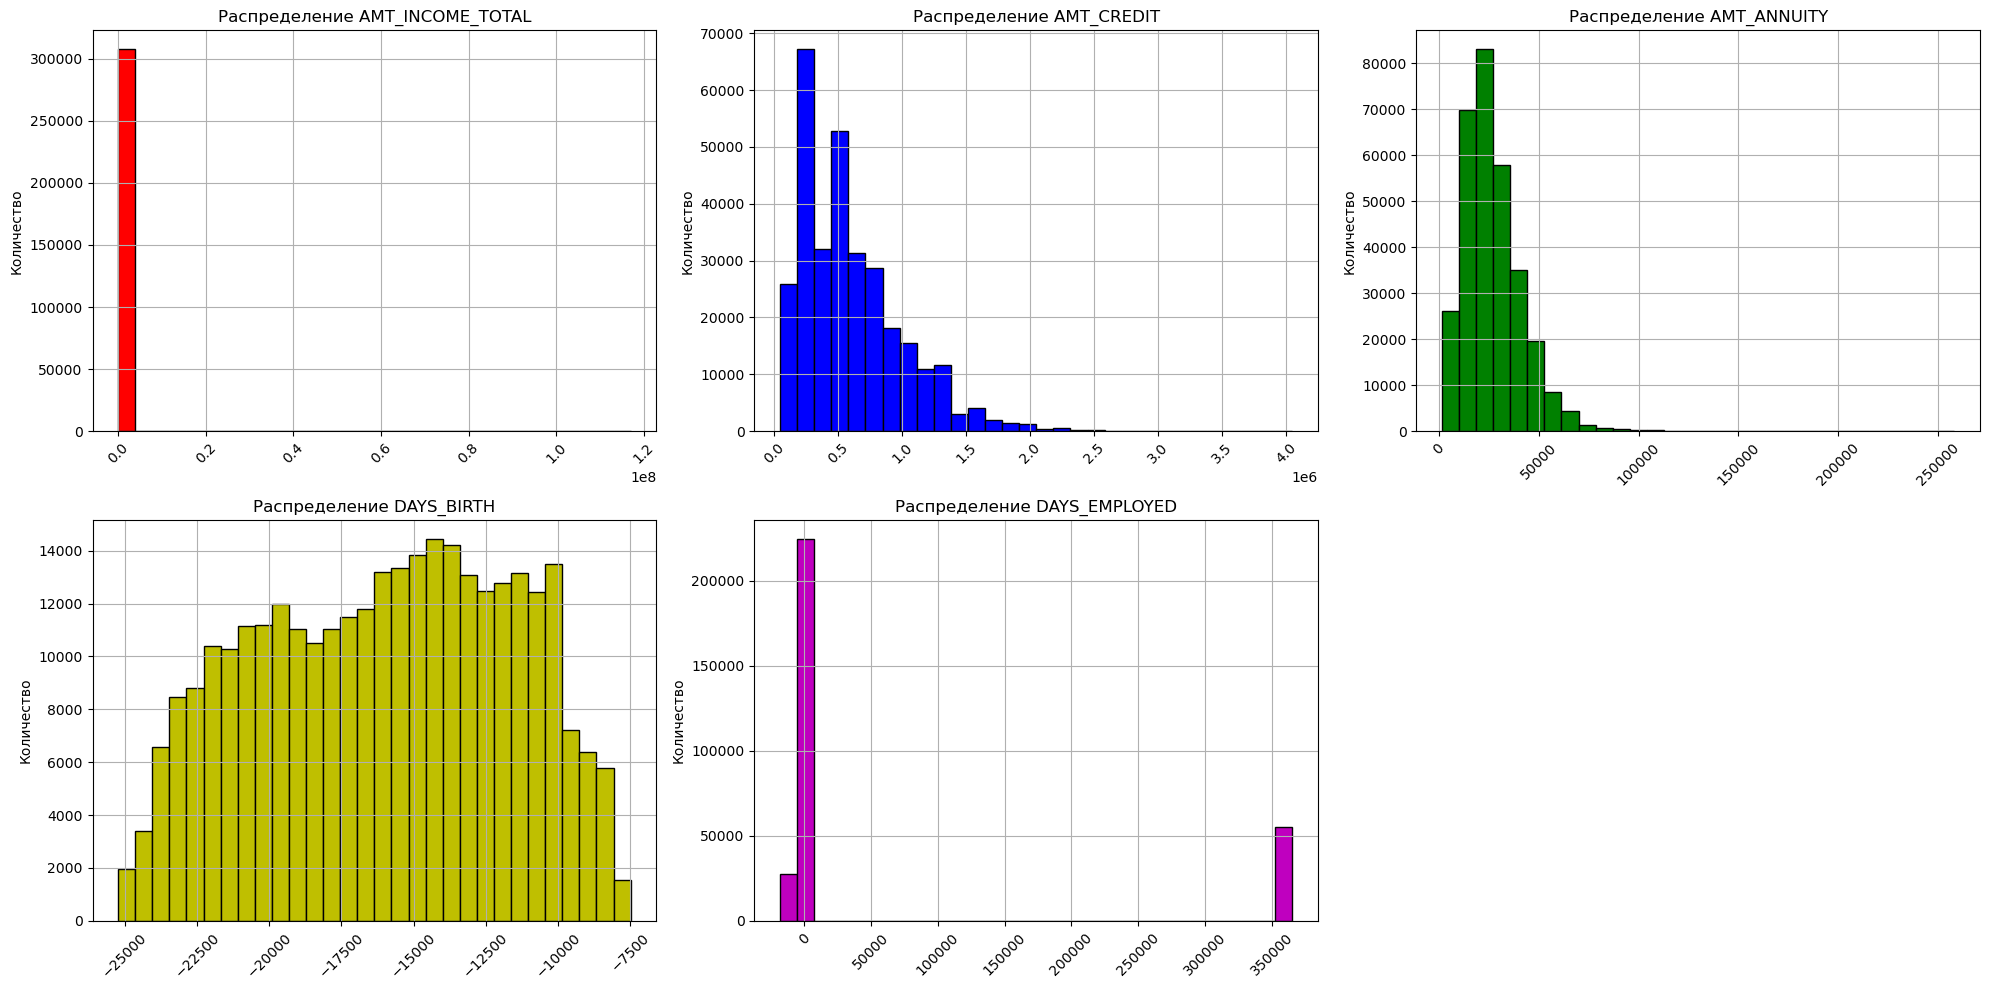

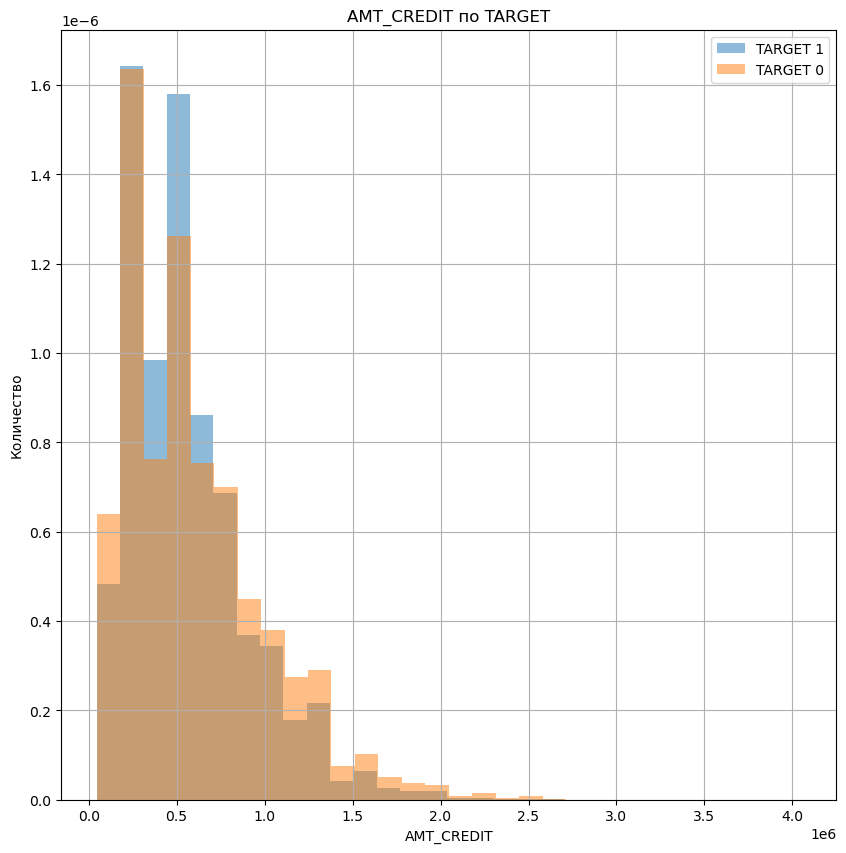

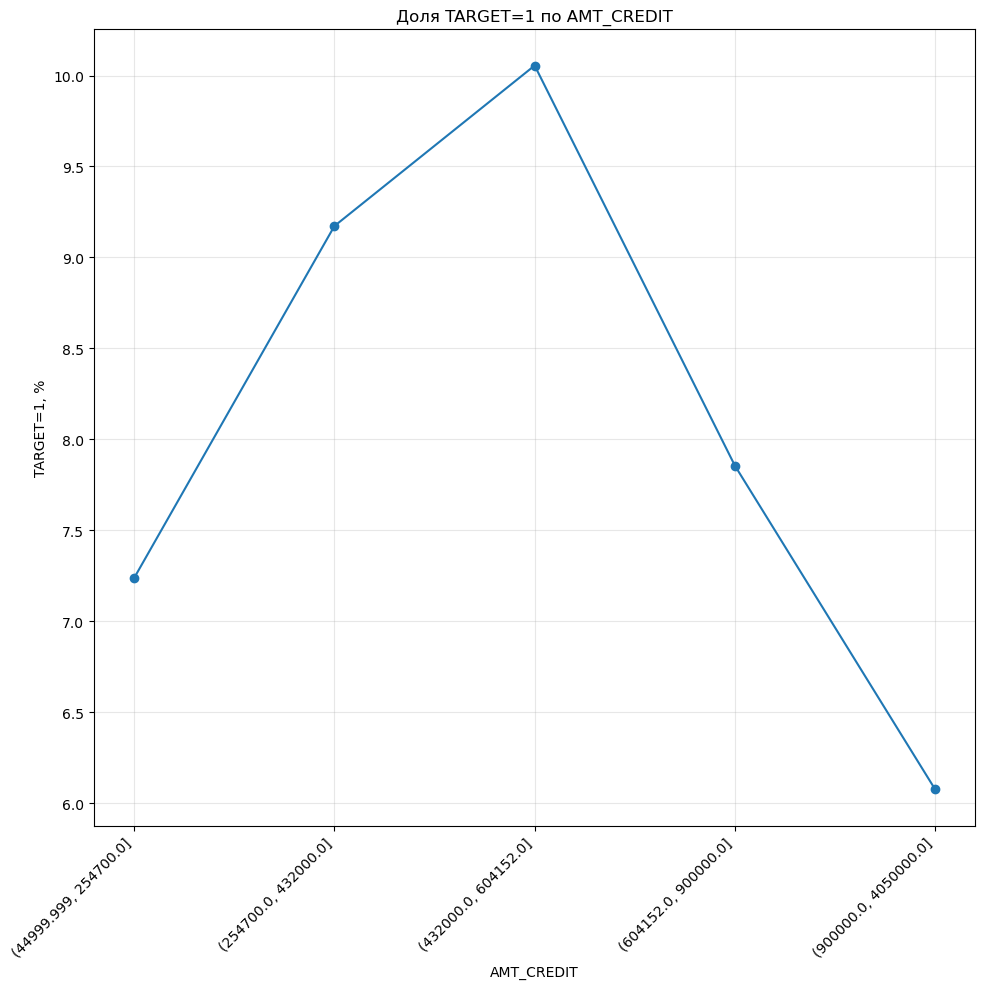

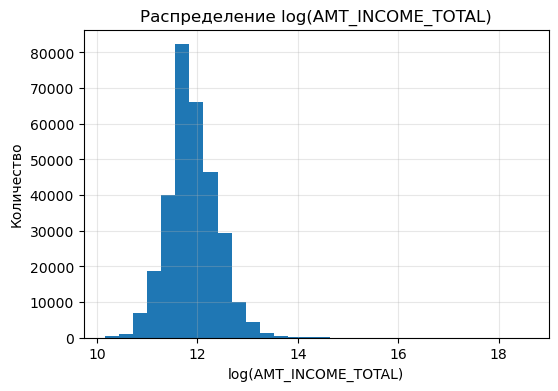

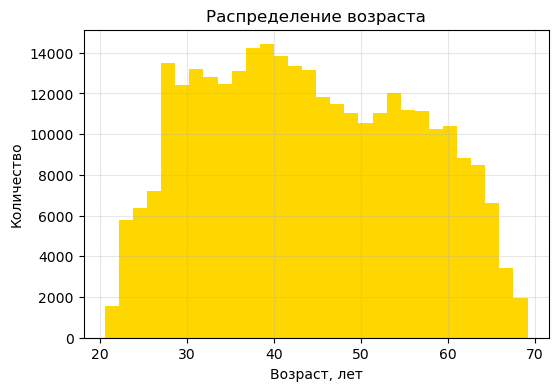

In [5]:
plot_target_distribution(train)
plot_categorical_target_rates(train)
plot_numeric_distributions(train)
plot_credit_amount_by_target(train)
plot_default_rate_by_credit_amount(train)
plot_income_and_age_distributions(train)


## Обучаем модели

### Запускаем обучение

In [6]:
artifacts = run_training_pipeline(
    final_feature_count=150,
    n_trials=1,
    timeout=1,
    submission_path="submission.csv",
)


(246008, 381) (61503, 381)
Сейчас обучаем LogisticRegression


2026/04/18 19:43:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 19:43:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Сейчас обучаем RandomForest


2026/04/18 19:44:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 19:44:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Сейчас обучаем LightGBM


2026/04/18 19:45:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 19:45:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Сейчас обучаем CatBoost


2026/04/18 19:50:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 19:50:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Начинаем Оптимизацию LightGBM


2026/04/18 20:04:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 20:04:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/18 20:06:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 20:06:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

### Проверяем метрики

In [7]:
baseline_summary = pd.DataFrame(
    [
        {
            "model": name,
            "accuracy": metrics["accuracy"],
            "roc_auc": metrics["roc_auc"],
            "pr_auc": metrics["pr_auc"],
        }
        for name, metrics in artifacts["baseline_results"].items()
    ]
).sort_values("pr_auc", ascending=False)
baseline_summary


,model,accuracy,roc_auc,pr_auc
2,LightGBM,0.920166,0.782807,0.281740
3,CatBoost,0.920020,0.779256,0.276506
0,LogisticRegression,0.919532,0.771930,0.258622
1,RandomForest,0.919272,0.758877,0.248282


### Сопоставляем baseline

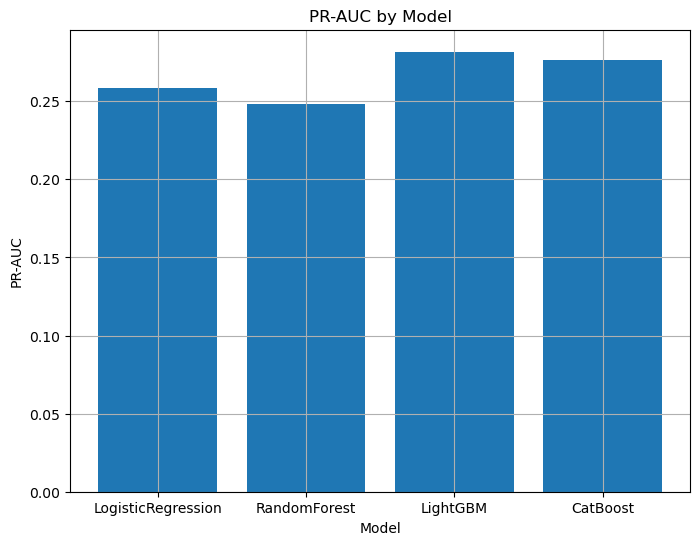

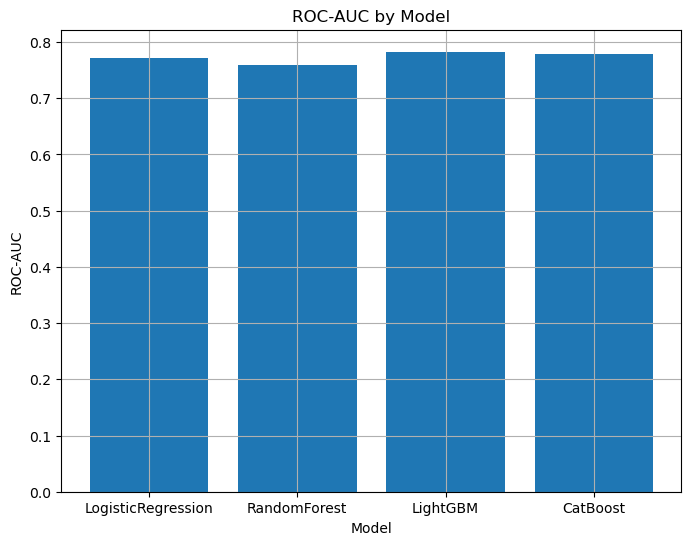

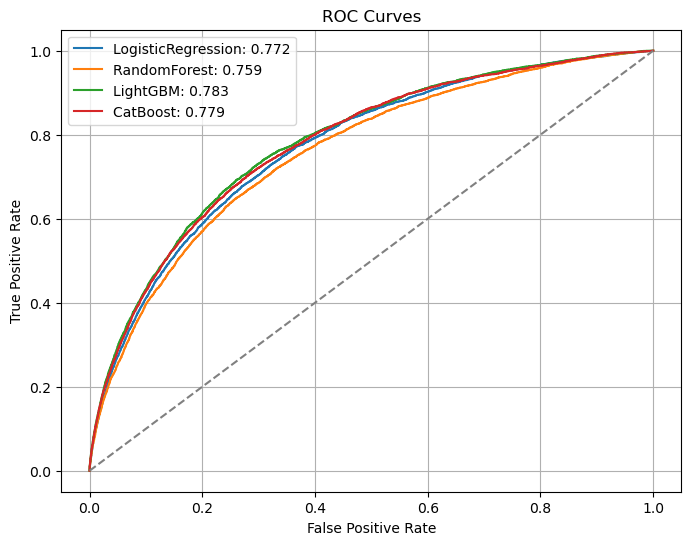

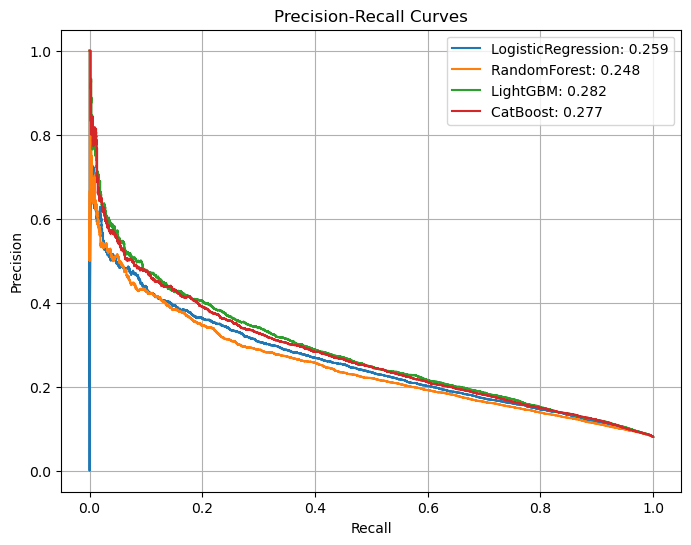

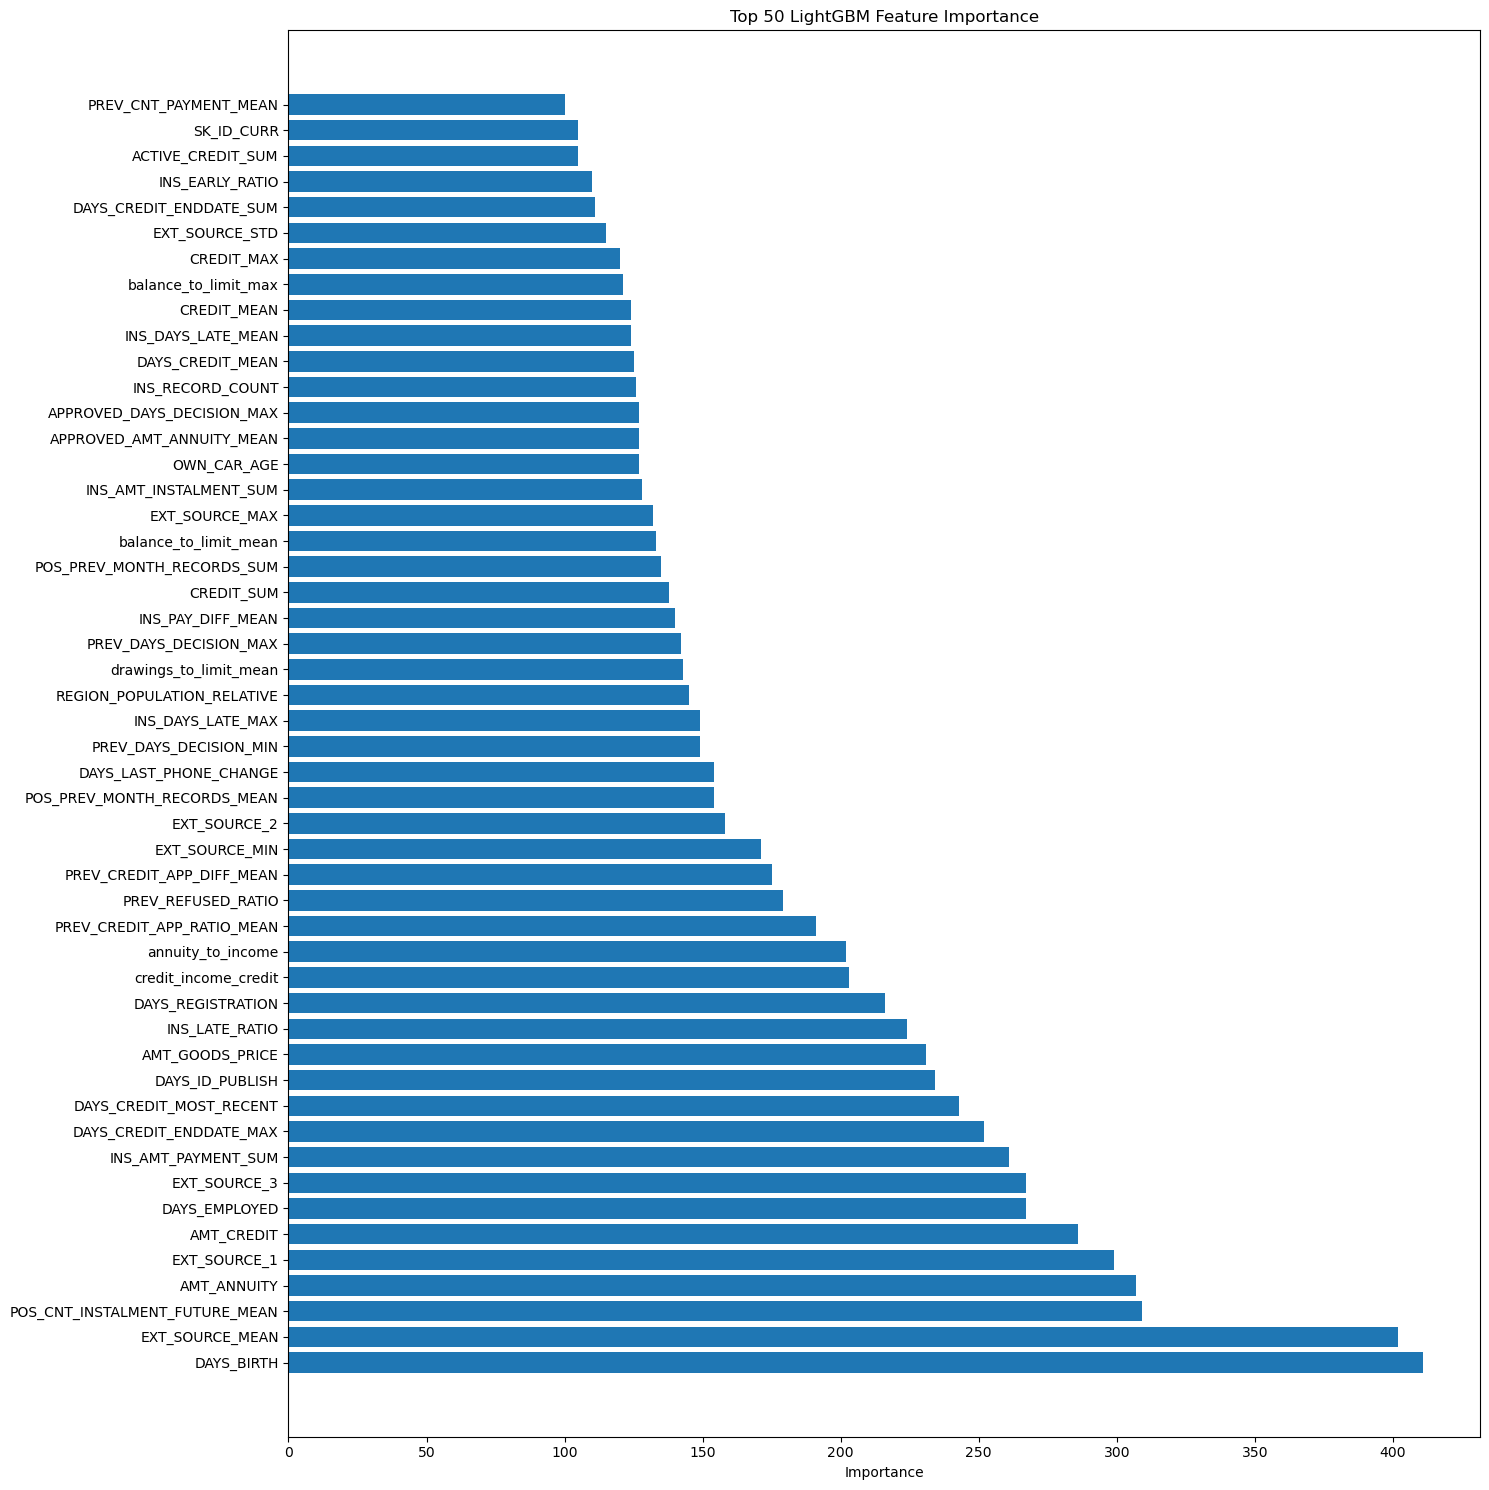

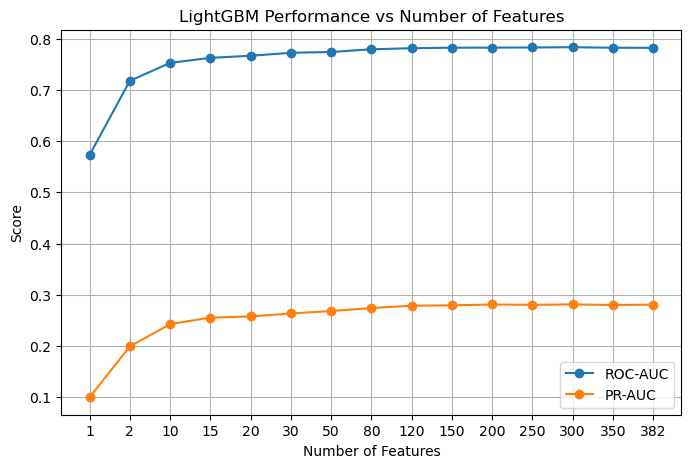

In [8]:
plot_baseline_metric_bars(artifacts["baseline_results"])
plot_baseline_curves(artifacts["baseline_results"])
plot_feature_importance(artifacts["feature_importance"], top_n=50)
plot_feature_count_experiment(artifacts["feature_count_results"])


### Разбираем параметры

In [ ]:
print("Best Optuna params:")
artifacts["optuna_results"]["best_params"]


### Проверяем submission

In [ ]:
artifacts["submission"].head()
